In [ ]:
%pip install scikit-learn matplotlib seaborn tqdm pandas

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [1]:
import os
import glob
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from tqdm import tqdm

In [3]:
class DVMColorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels =[]
        
        valid_colors = ['Black', 'White', 'Red', 'Blue', 'Silver', 'Grey', 'Yellow', 'Green', 'Brown']
        self.classes = sorted(valid_colors)
        self.color_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        print("Ищу картинки, жди...")
        all_files = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True)
        
        for file_path in all_files:
            filename = os.path.basename(file_path)
            parts = filename.split('$$')
            
            found_color = [p for p in parts if p in valid_colors]
            
            if len(found_color) > 0:
                color = found_color[0]
                self.image_paths.append(file_path)
                self.labels.append(self.color_to_idx[color])
                
        print(f"Найдено подходящих машин: {len(self.image_paths)}")
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [4]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

DATA_DIR = './dataset'
full_dataset = DVMColorDataset(root_dir=DATA_DIR)
NUM_CLASSES = len(full_dataset.classes)
print(f"Оставили {NUM_CLASSES} классов: {full_dataset.classes}")

indices = list(range(len(full_dataset)))
targets = full_dataset.labels

train_idx, temp_idx, _, temp_targets = train_test_split(indices, targets, test_size=0.3, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_targets, random_state=42)

class MySubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.subset)

train_dataset = MySubset(Subset(full_dataset, train_idx), transform=transform_train)
val_dataset = MySubset(Subset(full_dataset, val_idx), transform=transform_test)
test_dataset = MySubset(Subset(full_dataset, test_idx), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Будем учить на: {device}")

Ищу картинки, жди...
Найдено подходящих машин: 57889
Оставили 9 классов: ['Black', 'Blue', 'Brown', 'Green', 'Grey', 'Red', 'Silver', 'White', 'Yellow']
Будем учить на: cuda


In [5]:
class MyCustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
def train_model(model, name, epochs=4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_loss': [], 'val_loss': [], 'train_f1':[], 'val_f1':[]}
    
    for epoch in range(epochs):
        model.train()
        train_loss, all_preds, all_labels = 0.0, [],[]
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_f1'].append(f1_score(all_labels, all_preds, average='macro'))
        
        model.eval()
        val_loss, all_preds_val, all_labels_val = 0.0, [],[]
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_preds_val.extend(preds.cpu().numpy())
                all_labels_val.extend(labels.cpu().numpy())
                
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_f1'].append(f1_score(all_labels_val, all_preds_val, average='macro'))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title(f'{name} - функция потерь (Loss)')
    ax1.legend()
    
    ax2.plot(history['train_f1'], label='Train F1', marker='o')
    ax2.plot(history['val_f1'], label='Val F1', marker='o')
    ax2.set_title(f'{name} - метрика F1_Macro')
    ax2.legend()
    plt.show()
    
    return model

def evaluate_on_test(model):
    model.eval()
    all_preds, all_labels = [],[]
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\nФинальный экзамен (тестовая выборка):")
    print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
    plt.xlabel('Предсказал')
    plt.ylabel('Реальный цвет')
    plt.title('Матрица ошибок')
    plt.show()

=== 1. Обучаем кастомную сверточную сеть (с нуля) ===


Epoch 4/4: 100%|██████████| 1267/1267 [03:06<00:00,  6.79it/s]


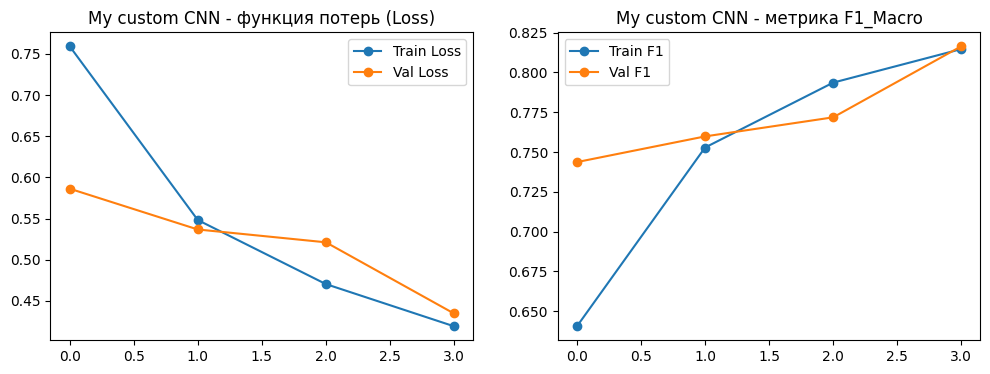


Финальный экзамен (тестовая выборка):
              precision    recall  f1-score   support

       Black       0.82      0.95      0.88      2148
        Blue       0.92      0.81      0.86      1273
       Brown       0.75      0.37      0.49       136
       Green       0.93      0.43      0.59       116
        Grey       0.80      0.67      0.73      1421
         Red       0.98      0.98      0.98       914
      Silver       0.80      0.86      0.83      1166
       White       0.92      0.96      0.94      1410
      Yellow       0.93      0.98      0.96       100

    accuracy                           0.86      8684
   macro avg       0.87      0.78      0.81      8684
weighted avg       0.86      0.86      0.86      8684



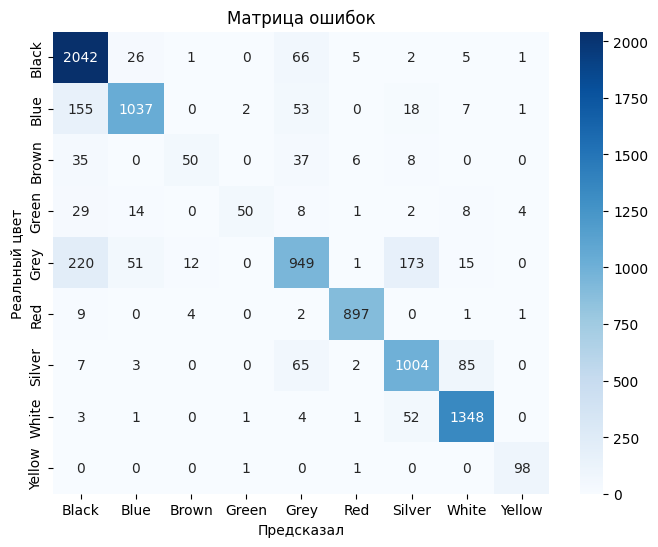


=== 2. Обучаем предобученную MobileNetV2 (Transfer Learning) ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\adm-user/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 11.7MB/s]
Epoch 4/4: 100%|██████████| 1267/1267 [04:10<00:00,  5.05it/s]


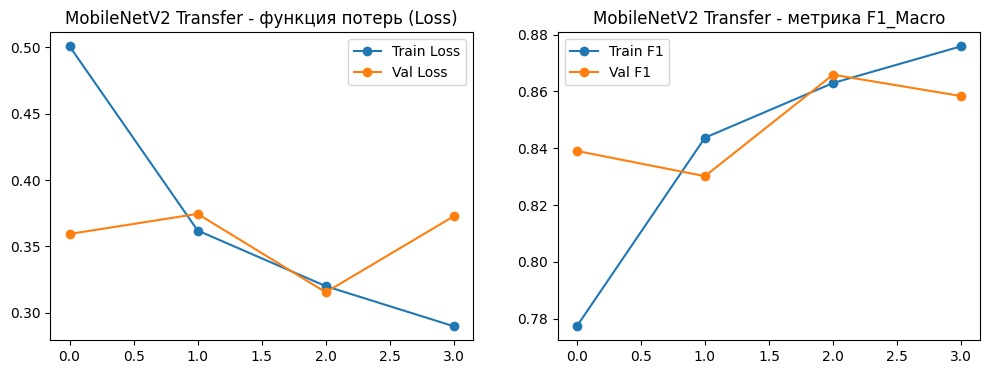


Финальный экзамен (тестовая выборка):
              precision    recall  f1-score   support

       Black       0.85      0.96      0.90      2148
        Blue       0.89      0.91      0.90      1273
       Brown       0.72      0.52      0.60       136
       Green       0.90      0.70      0.79       116
        Grey       0.82      0.77      0.79      1421
         Red       0.99      0.98      0.99       914
      Silver       0.80      0.84      0.82      1166
       White       0.98      0.86      0.92      1410
      Yellow       0.98      0.91      0.94       100

    accuracy                           0.88      8684
   macro avg       0.88      0.83      0.85      8684
weighted avg       0.88      0.88      0.88      8684



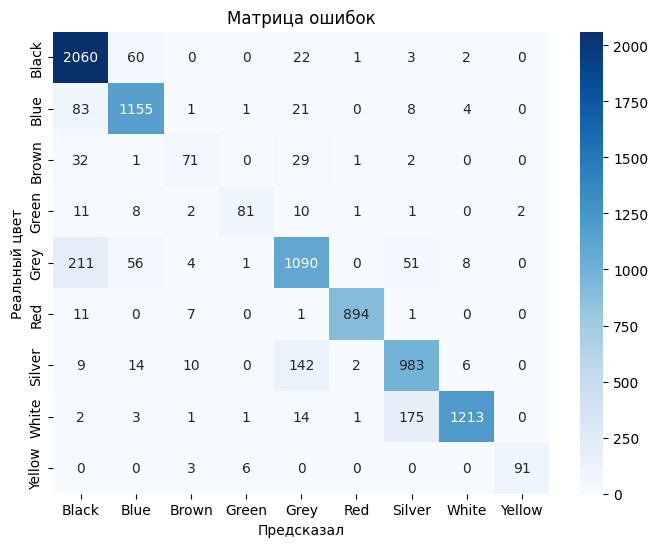


=== 3. Обучаем предобученную ShuffleNet (Transfer Learning) ===
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to C:\Users\adm-user/.cache\torch\hub\checkpoints\shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 11.5MB/s]
Epoch 4/4: 100%|██████████| 1267/1267 [03:29<00:00,  6.05it/s]


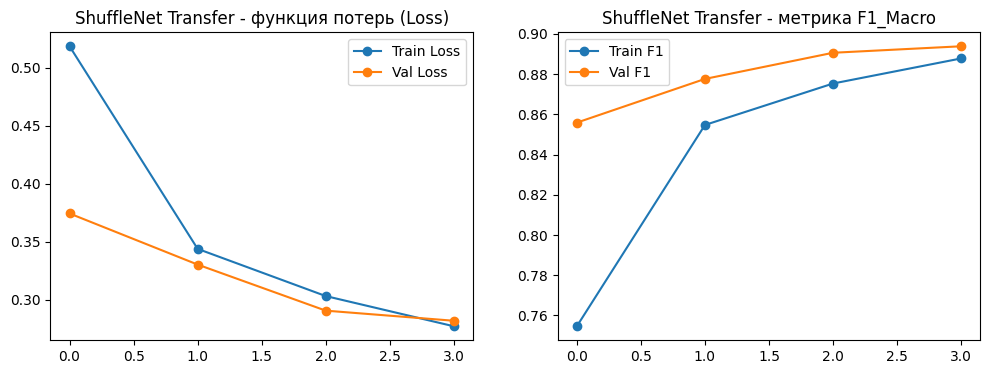


Финальный экзамен (тестовая выборка):
              precision    recall  f1-score   support

       Black       0.94      0.91      0.93      2148
        Blue       0.93      0.91      0.92      1273
       Brown       0.76      0.68      0.72       136
       Green       0.86      0.82      0.84       116
        Grey       0.83      0.86      0.84      1421
         Red       0.99      0.99      0.99       914
      Silver       0.89      0.88      0.88      1166
       White       0.93      0.99      0.96      1410
      Yellow       0.96      0.92      0.94       100

    accuracy                           0.91      8684
   macro avg       0.90      0.88      0.89      8684
weighted avg       0.91      0.91      0.91      8684



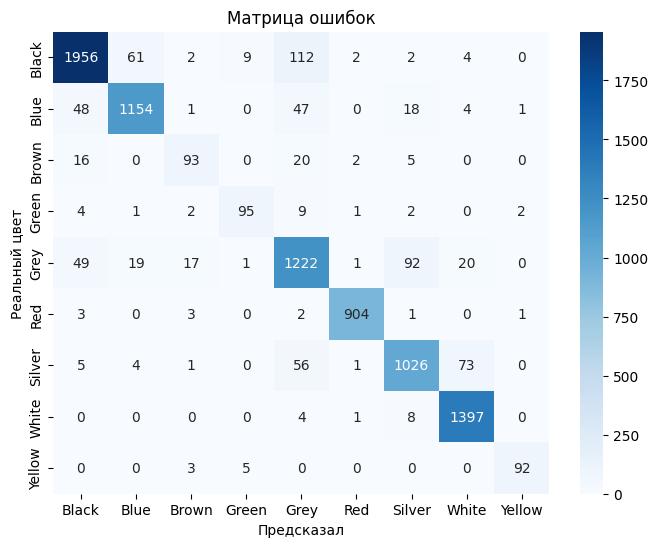

In [7]:
print("=== 1. Обучаем кастомную сверточную сеть (с нуля) ===")
model_custom = MyCustomCNN(NUM_CLASSES)
model_custom = train_model(model_custom, "My custom CNN", epochs=4)
evaluate_on_test(model_custom)

print("\n=== 2. Обучаем предобученную MobileNetV2 (Transfer Learning) ===")
model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.classifier[1].in_features, NUM_CLASSES)
model_mobilenet = train_model(model_mobilenet, "MobileNetV2 Transfer", epochs=4)
evaluate_on_test(model_mobilenet)

print("\n=== 3. Обучаем предобученную ShuffleNet (Transfer Learning) ===")
model_shufflenet = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT)
model_shufflenet.fc = nn.Linear(model_shufflenet.fc.in_features, NUM_CLASSES)
model_shufflenet = train_model(model_shufflenet, "ShuffleNet Transfer", epochs=4)
evaluate_on_test(model_shufflenet)

Демонстрация инференса:


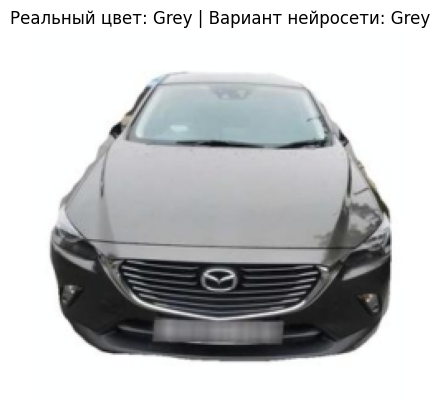

In [23]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def manual_inference(model):
    model.eval()
    idx = random.randint(0, len(test_dataset)-1)
    img_tensor, label_idx = test_dataset[idx]
    
    img_to_show = img_tensor.permute(1, 2, 0).numpy()
    img_to_show = std * img_to_show + mean 
    img_to_show = np.clip(img_to_show, 0, 1)
    
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)
        
    true_color = full_dataset.classes[label_idx]
    pred_color = full_dataset.classes[pred.item()]
    
    plt.imshow(img_to_show)
    plt.title(f"Реальный цвет: {true_color} | Вариант нейросети: {pred_color}")
    plt.axis('off')
    plt.show()

print("Демонстрация инференса:")
manual_inference(model_custom)